
Transition-zone sensitivity:
 Threshold_m  Transition_Area_km2  Percent_of_Compound_Flooded_Area  Mean_Compound_Depth_m  Mean_Surge_Depth_m  Mean_River_Depth_m  Mean_Compound_minus_Surge_m  Mean_Compound_minus_River_m
        0.05              2364.28                            17.038                  4.822               4.598               0.362                        0.224                        4.460
        0.10               967.28                             6.971                  4.474               4.027               0.254                        0.447                        4.220
        0.20               562.68                             4.055                  4.726               4.058               0.414                        0.668                        4.312


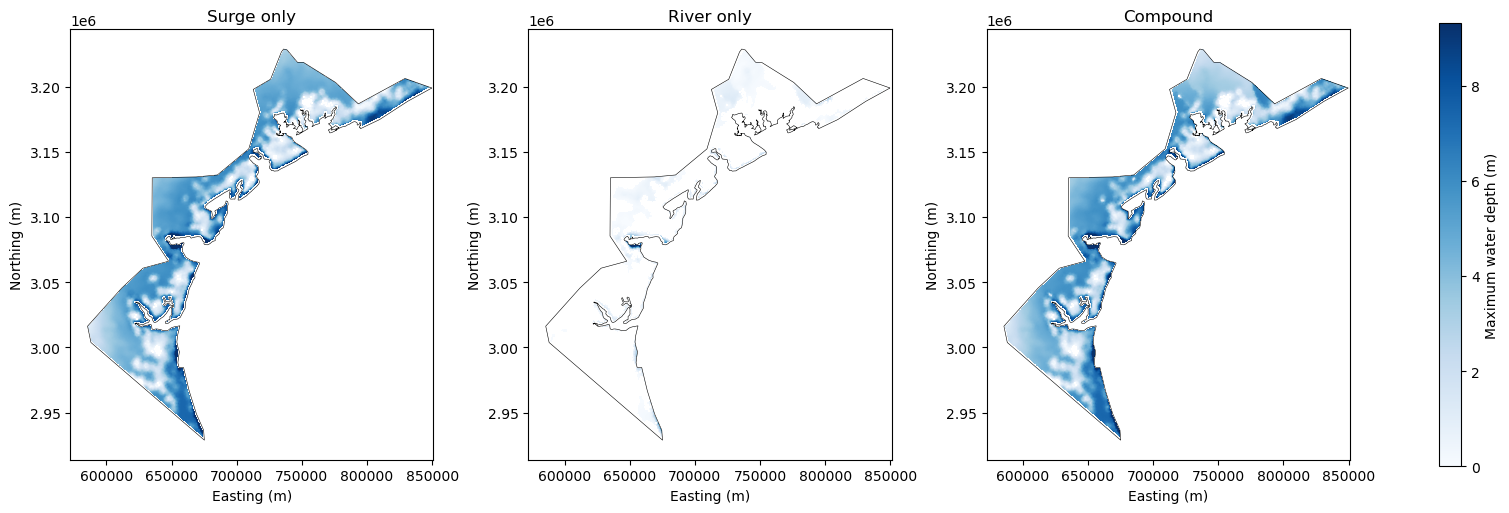

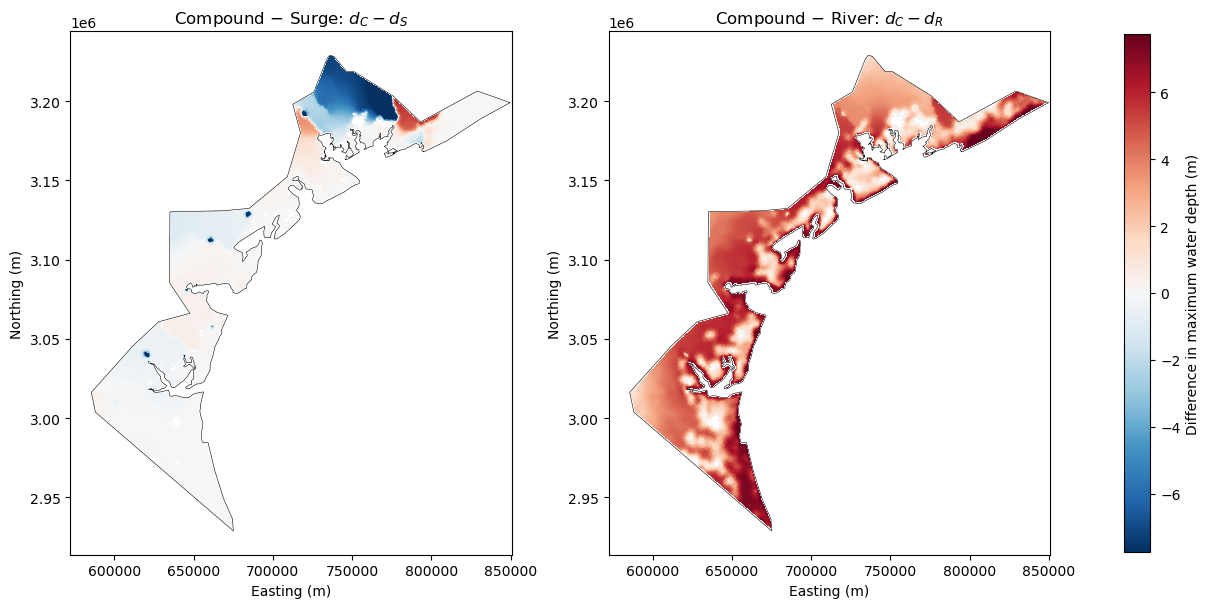

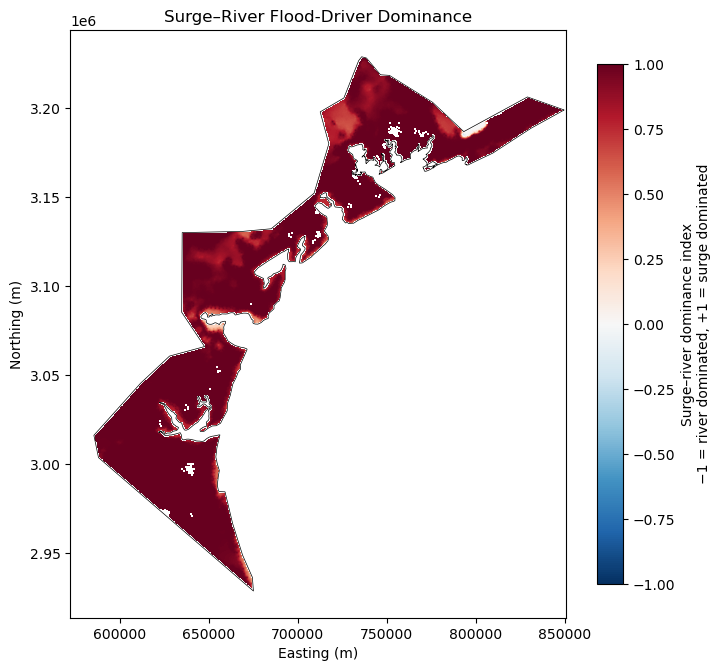

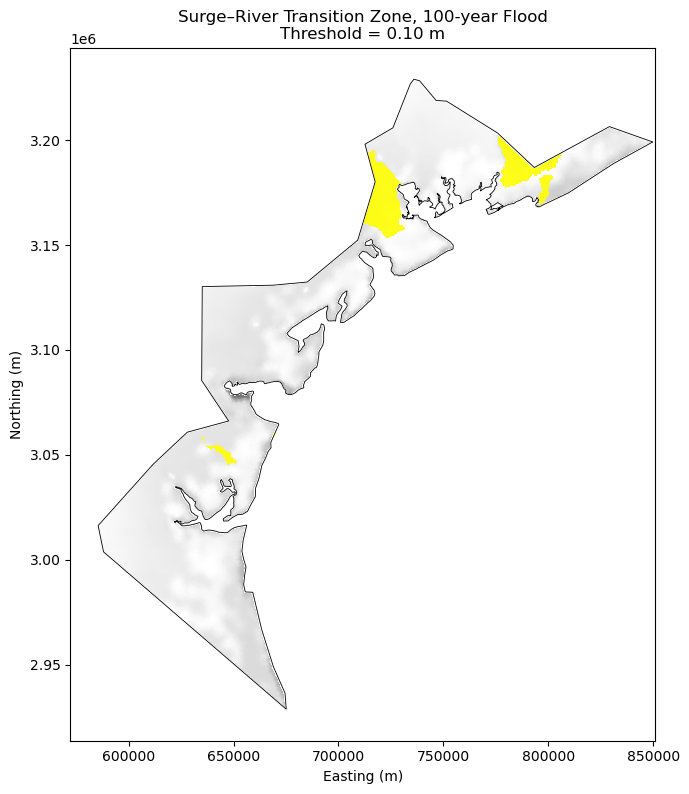

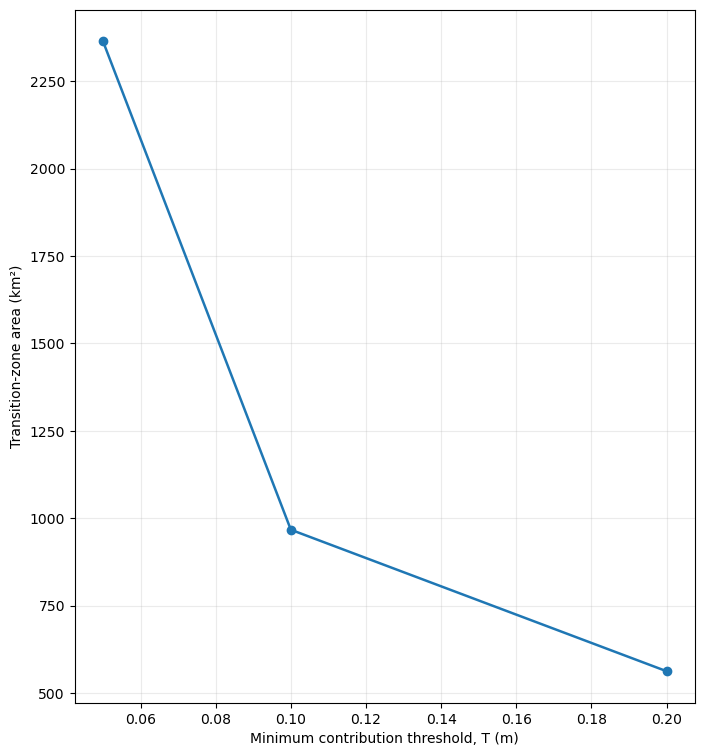


Analysis completed.
Outputs saved to:
D:\Phd Research\Final_Raster\Surge_River_Transition


In [17]:
import rasterio, geopandas as gpd, numpy as np, pandas as pd, matplotlib.pyplot as plt
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from rasterio.features import shapes
from shapely.geometry import shape
from pathlib import Path

# ============================================================
# FILE PATHS
# ============================================================
compound_file = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"
surge_file    = r"D:\Phd Research\Final_Raster\inundation for only storm surge 100 yr_v2_stat.tif"
river_file    = r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif"
land_file     = r"zip://D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

out_dir = Path(r"D:\Phd Research\Final_Raster\Surge_River_Transition")
out_dir.mkdir(parents=True, exist_ok=True)

# Thresholds for sensitivity analysis (m)
thresholds = [0.05, 0.10, 0.20]
main_threshold = 0.10

# Ignore tiny numerical wetting depths
wet_threshold = 0.01

# ============================================================
# READ COMPOUND RASTER AS REFERENCE GRID
# ============================================================
with rasterio.open(compound_file) as src:
    compound = src.read(1).astype("float32")
    profile = src.profile.copy()
    transform = src.transform
    crs = src.crs
    nodata = src.nodata
    bounds = src.bounds
    width, height = src.width, src.height

compound[compound == nodata] = np.nan if nodata is not None else compound[compound == nodata]

# ============================================================
# FUNCTION: READ + ALIGN OTHER RASTERS TO COMPOUND GRID
# ============================================================
def read_align_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        src_nodata = src.nodata

        if src_nodata is not None:
            arr[arr == src_nodata] = np.nan

        same_grid = (
            src.crs == crs and
            src.transform == transform and
            src.width == width and
            src.height == height
        )

        if same_grid:
            return arr

        dst = np.full((height, width), np.nan, dtype="float32")

        reproject(
            source=arr,
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=crs,
            src_nodata=np.nan,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear
        )
        return dst

surge = read_align_raster(surge_file)
river = read_align_raster(river_file)

# ============================================================
# READ LAND BOUNDARY AND CREATE LAND MASK
# ============================================================
land = gpd.read_file(land_file)

if land.crs != crs:
    land = land.to_crs(crs)

from rasterio.features import geometry_mask

land_mask = geometry_mask(
    land.geometry,
    out_shape=(height, width),
    transform=transform,
    invert=True
)

# Restrict analysis to land
compound[~land_mask] = np.nan
surge[~land_mask] = np.nan
river[~land_mask] = np.nan

# Treat negative water depths as dry / numerical artifacts
compound[compound < 0] = 0
surge[surge < 0] = 0
river[river < 0] = 0

# ============================================================
# VALID/WET DOMAIN
# ============================================================
valid = np.isfinite(compound) & np.isfinite(surge) & np.isfinite(river)

# Any scenario showing meaningful inundation
wet = valid & ((compound > wet_threshold) |
               (surge > wet_threshold) |
               (river > wet_threshold))

# ============================================================
# COMPOUND ENHANCEMENT
# ============================================================
# Effect of adding river to surge
delta_CS = compound - surge

# Effect of adding surge to river
delta_CR = compound - river

# Negative values can occur because of hydrodynamic nonlinearities;
# retain them in difference rasters, but they do not count as
# "appreciable positive contribution" for transition classification.

# ============================================================
# SINGLE-DRIVER DOMINANCE INDEX
# ============================================================
# Because these rasters are WATER DEPTHS, this normalized index is suitable:
#
# D = (Surge - River) / (Surge + River)
#
# D -> +1 = surge dominated
# D -> -1 = river dominated
# D ~ 0  = similar single-driver depths
# ============================================================
denom = surge + river

dominance = np.full(compound.shape, np.nan, dtype="float32")
idx = wet & (denom > wet_threshold)
dominance[idx] = (surge[idx] - river[idx]) / denom[idx]

# ============================================================
# FUNCTION TO WRITE GEOTIFF
# ============================================================
def write_raster(array, filename, dtype="float32", nodata_out=-9999):
    out = np.where(np.isfinite(array), array, nodata_out)

    p = profile.copy()
    p.update(
        dtype=dtype,
        count=1,
        nodata=nodata_out,
        compress="lzw"
    )

    with rasterio.open(out_dir / filename, "w", **p) as dst:
        dst.write(out.astype(dtype), 1)

# Save basic diagnostic rasters
write_raster(delta_CS, "Compound_minus_Surge.tif")
write_raster(delta_CR, "Compound_minus_River.tif")
write_raster(dominance, "Surge_River_Dominance_Index.tif")

# ============================================================
# PIXEL AREA
# ============================================================
pixel_area_m2 = abs(transform.a * transform.e)
pixel_area_km2 = pixel_area_m2 / 1e6

# ============================================================
# TRANSITION ZONE SENSITIVITY ANALYSIS
# ============================================================
summary = []

for T in thresholds:

    # Transition zone:
    # compound must exceed BOTH single-driver depths by at least T
    transition = (
        wet &
        (delta_CS >= T) &
        (delta_CR >= T)
    )

    area_km2 = transition.sum() * pixel_area_km2

    flooded_compound_area = (valid & (compound > wet_threshold)).sum() * pixel_area_km2

    pct_compound = 100 * area_km2 / flooded_compound_area if flooded_compound_area > 0 else np.nan

    summary.append({
        "Threshold_m": T,
        "Transition_Area_km2": area_km2,
        "Percent_of_Compound_Flooded_Area": pct_compound,
        "Mean_Compound_Depth_m": np.nanmean(compound[transition]) if transition.any() else np.nan,
        "Mean_Surge_Depth_m": np.nanmean(surge[transition]) if transition.any() else np.nan,
        "Mean_River_Depth_m": np.nanmean(river[transition]) if transition.any() else np.nan,
        "Mean_Compound_minus_Surge_m": np.nanmean(delta_CS[transition]) if transition.any() else np.nan,
        "Mean_Compound_minus_River_m": np.nanmean(delta_CR[transition]) if transition.any() else np.nan
    })

    transition_raster = np.full(compound.shape, np.nan, dtype="float32")
    transition_raster[valid] = 0
    transition_raster[transition] = 1

    write_raster(
        transition_raster,
        f"Transition_zone_{int(T*100):02d}cm.tif"
    )

summary_df = pd.DataFrame(summary)
summary_df.to_csv(out_dir / "Transition_zone_threshold_sensitivity.csv", index=False)

print("\nTransition-zone sensitivity:")
print(summary_df.round(3).to_string(index=False))

# ============================================================
# MAIN 0.10-m CLASSIFICATION
# ============================================================
T = main_threshold

transition = (
    wet &
    (delta_CS >= T) &
    (delta_CR >= T)
)

# ------------------------------------------------------------
# Classification:
# 0 = dry/no meaningful flood
# 1 = river dominated
# 2 = surge-river transition
# 3 = surge dominated
# 4 = mixed/ambiguous
#
# For non-transition cells:
# compare compound proximity to single-driver simulations.
# If compound is closer to surge-only -> surge dominates.
# If compound is closer to river-only -> river dominates.
# ------------------------------------------------------------
classification = np.full(compound.shape, np.nan, dtype="float32")
classification[valid] = 0

surge_distance = np.abs(compound - surge)
river_distance = np.abs(compound - river)

river_dom = wet & ~transition & (river_distance < surge_distance)
surge_dom = wet & ~transition & (surge_distance < river_distance)
mixed = wet & ~transition & np.isclose(surge_distance, river_distance, atol=0.01)

classification[river_dom] = 1
classification[transition] = 2
classification[surge_dom] = 3
classification[mixed] = 4

write_raster(classification, "Surge_River_Flood_Regime_10cm.tif")

# ============================================================
# TRANSITION ZONE TO SHAPEFILE
# ============================================================
transition_uint8 = transition.astype("uint8")

geoms = [
    {"properties": {"Transition": int(v)}, "geometry": shape(g)}
    for g, v in shapes(
        transition_uint8,
        mask=transition,
        transform=transform
    )
    if v == 1
]

if geoms:
    transition_gdf = gpd.GeoDataFrame.from_features(geoms, crs=crs)

    # Dissolve adjacent cells/polygons into one multipart feature
    transition_gdf = transition_gdf.dissolve(by="Transition").reset_index()

    # Calculate polygon area
    transition_gdf["Area_km2"] = transition_gdf.geometry.area / 1e6

    transition_gdf.to_file(
        out_dir / "Surge_River_Transition_Zone_10cm.shp"
    )

# ============================================================
# FIGURE 1: THREE ORIGINAL FLOOD DEPTH MAPS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)

datasets = [
    (surge, "Surge only"),
    (river, "River only"),
    (compound, "Compound")
]

vmax = np.nanpercentile(compound[compound > wet_threshold], 98)

for ax, (data, title) in zip(axes, datasets):
    im = ax.imshow(
        np.ma.masked_where(~land_mask | (data <= wet_threshold), data),
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        origin="upper",
        vmin=0,
        vmax=vmax,
        cmap="Blues"
    )

    land.boundary.plot(ax=ax, linewidth=0.4, color="black")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")

cbar = fig.colorbar(im, ax=axes, shrink=0.75)
cbar.set_label("Maximum water depth (m)")

plt.savefig(out_dir / "Surge_River_Compound_Depths.png", dpi=400, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 2: COMPOUND ENHANCEMENT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 7), constrained_layout=True)

for ax, data, title in [
    (axes[0], delta_CS, r"Compound − Surge: $d_C-d_S$"),
    (axes[1], delta_CR, r"Compound − River: $d_C-d_R$")
]:

    masked = np.ma.masked_where(~wet, data)

    lim = np.nanpercentile(np.abs(data[wet]), 98)

    im = ax.imshow(
        masked,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        origin="upper",
        cmap="RdBu_r",
        vmin=-lim,
        vmax=lim
    )

    land.boundary.plot(ax=ax, linewidth=0.4, color="black")
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")

cbar = fig.colorbar(im, ax=axes, shrink=0.75)
cbar.set_label("Difference in maximum water depth (m)")

plt.savefig(out_dir / "Compound_Enhancement_Maps.png", dpi=400, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 3: DOMINANCE INDEX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 9))

im = ax.imshow(
    np.ma.masked_invalid(dominance),
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

land.boundary.plot(ax=ax, linewidth=0.5, color="black")

cbar = plt.colorbar(im, ax=ax, shrink=0.75)
cbar.set_label("Surge–river dominance index\n−1 = river dominated, +1 = surge dominated")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Surge–River Flood-Driver Dominance")
ax.set_aspect("equal")

plt.savefig(out_dir / "Surge_River_Dominance_Index.png", dpi=400, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 4: FINAL TRANSITION-ZONE MAP
# ============================================================
fig, ax = plt.subplots(figsize=(8, 9))

# Compound inundation as background
background = np.ma.masked_where(~wet, compound)

im = ax.imshow(
    background,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper",
    cmap="Greys",
    alpha=0.55
)

# Transition cells
transition_plot = np.ma.masked_where(~transition, transition.astype(float))

ax.imshow(
    transition_plot,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper",
    cmap="autumn",
    vmin=0,
    vmax=1,
    alpha=0.9
)

land.boundary.plot(ax=ax, linewidth=0.6, color="black")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Surge–River Transition Zone, 100-year Flood\nThreshold = {T:.2f} m")
ax.set_aspect("equal")

plt.savefig(out_dir / "Surge_River_Transition_Zone_10cm.png", dpi=400, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 5: THRESHOLD SENSITIVITY
# ============================================================
fig, ax = plt.subplots(figsize=(8, 9))

ax.plot(
    summary_df["Threshold_m"],
    summary_df["Transition_Area_km2"],
    marker="o",
    linewidth=1.8
)

ax.set_xlabel("Minimum contribution threshold, T (m)")
ax.set_ylabel("Transition-zone area (km²)")
ax.grid(alpha=0.25)

plt.savefig(out_dir / "Transition_Threshold_Sensitivity.png", dpi=400, bbox_inches="tight")
plt.show()

print("\nAnalysis completed.")
print(f"Outputs saved to:\n{out_dir}")


Transition-zone sensitivity:
 Threshold_m  Transition_Area_km2  Percent_of_Compound_Flooded_Area  Mean_Compound_Depth_m  Mean_Surge_Depth_m  Mean_River_Depth_m  Mean_Compound_minus_Surge_m  Mean_Compound_minus_River_m
        0.05              2364.28                            17.038                  4.822               4.598               0.362                        0.224                        4.460
        0.10               967.28                             6.971                  4.474               4.027               0.254                        0.447                        4.220
        0.20               562.68                             4.055                  4.726               4.058               0.414                        0.668                        4.312


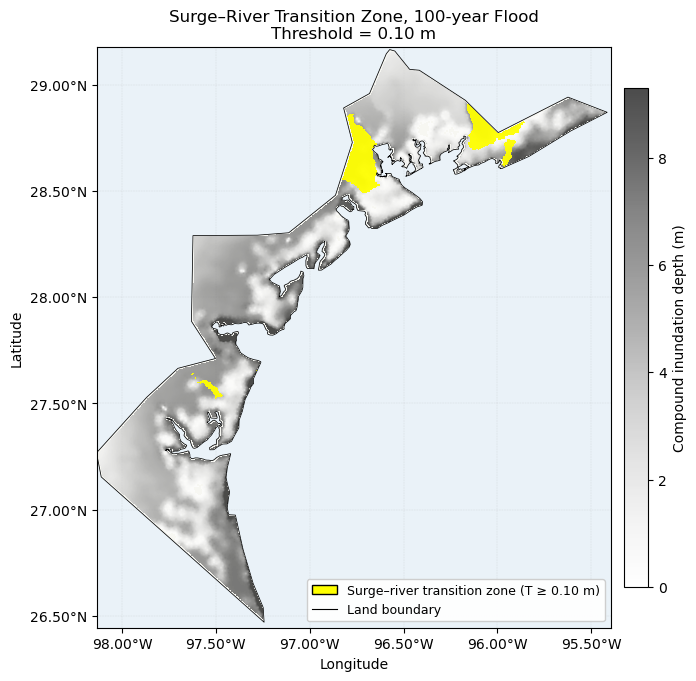

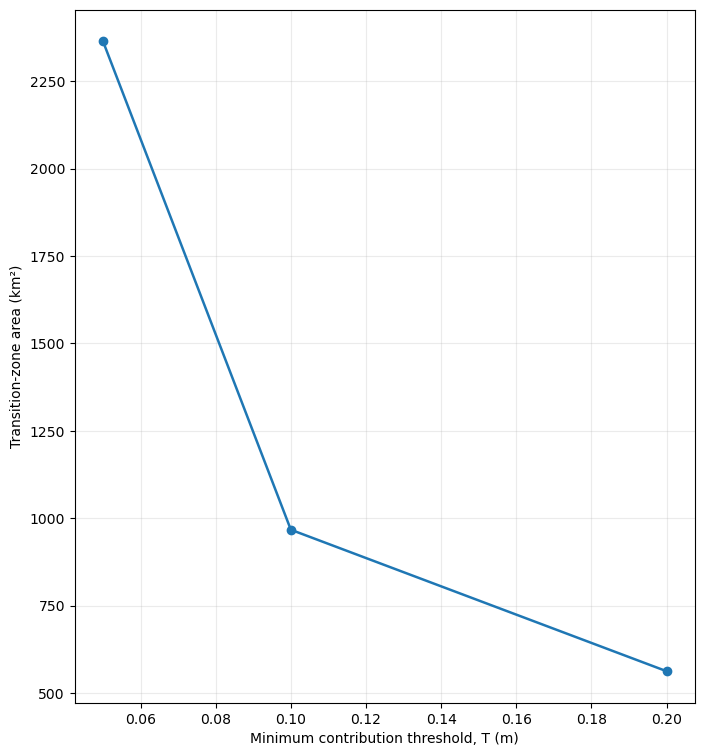


Analysis completed.
Outputs saved to:
D:\Phd Research\Final_Raster\Surge_River_Transition


In [19]:
import rasterio, geopandas as gpd, numpy as np, pandas as pd, matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.features import shapes, geometry_mask
from shapely.geometry import shape
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
import contextily as ctx

# ============================================================
# FILE PATHS
# ============================================================
compound_file = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"
surge_file    = r"D:\Phd Research\Final_Raster\inundation for only storm surge 100 yr_v2_stat.tif"
river_file    = r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif"
land_file     = r"zip://D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
out_dir=Path(r"D:\Phd Research\Final_Raster\Surge_River_Transition"); out_dir.mkdir(parents=True,exist_ok=True)

# Thresholds for sensitivity analysis
thresholds=[0.05,0.10,0.20]
main_threshold=0.10
wet_threshold=0.01

# ============================================================
# READ COMPOUND RASTER AS REFERENCE GRID
# ============================================================
with rasterio.open(compound_file) as src:
    compound=src.read(1).astype("float32"); profile=src.profile.copy(); transform=src.transform
    crs=src.crs; nodata=src.nodata; bounds=src.bounds; width,height=src.width,src.height

if nodata is not None: compound[compound==nodata]=np.nan

# ============================================================
# READ + ALIGN OTHER RASTERS TO COMPOUND GRID
# ============================================================
def read_align_raster(path):
    with rasterio.open(path) as src:
        arr=src.read(1).astype("float32"); src_nodata=src.nodata
        if src_nodata is not None: arr[arr==src_nodata]=np.nan
        if src.crs==crs and src.transform==transform and src.width==width and src.height==height: return arr
        dst=np.full((height,width),np.nan,dtype="float32")
        reproject(arr,dst,src_transform=src.transform,src_crs=src.crs,dst_transform=transform,dst_crs=crs,
                  src_nodata=np.nan,dst_nodata=np.nan,resampling=Resampling.bilinear)
        return dst

surge=read_align_raster(surge_file)
river=read_align_raster(river_file)

# ============================================================
# READ LAND BOUNDARY AND CREATE LAND MASK
# ============================================================
land=gpd.read_file(land_file)
if land.crs!=crs: land=land.to_crs(crs)

land_mask=geometry_mask(land.geometry,out_shape=(height,width),transform=transform,invert=True)

# Restrict analysis to land
compound[~land_mask]=np.nan; surge[~land_mask]=np.nan; river[~land_mask]=np.nan

# Treat negative depths as dry / numerical artifacts
compound[compound<0]=0; surge[surge<0]=0; river[river<0]=0

# ============================================================
# VALID / WET DOMAIN
# ============================================================
valid=np.isfinite(compound)&np.isfinite(surge)&np.isfinite(river)
wet=valid&((compound>wet_threshold)|(surge>wet_threshold)|(river>wet_threshold))

# ============================================================
# COMPOUND ENHANCEMENT
# ============================================================
# Compound minus surge-only
delta_CS=compound-surge

# Compound minus river-only
delta_CR=compound-river

# ============================================================
# SINGLE-DRIVER DOMINANCE INDEX
# D = (Surge - River) / (Surge + River)
# +1 = surge dominated; -1 = river dominated; 0 = similar
# ============================================================
denom=surge+river
dominance=np.full(compound.shape,np.nan,dtype="float32")
idx=wet&(denom>wet_threshold)
dominance[idx]=(surge[idx]-river[idx])/denom[idx]

# ============================================================
# FUNCTION TO WRITE GEOTIFF
# ============================================================
def write_raster(array,filename,dtype="float32",nodata_out=-9999):
    out=np.where(np.isfinite(array),array,nodata_out)
    p=profile.copy(); p.update(dtype=dtype,count=1,nodata=nodata_out,compress="lzw")
    with rasterio.open(out_dir/filename,"w",**p) as dst: dst.write(out.astype(dtype),1)

# Save diagnostic rasters
write_raster(delta_CS,"Compound_minus_Surge.tif")
write_raster(delta_CR,"Compound_minus_River.tif")
write_raster(dominance,"Surge_River_Dominance_Index.tif")

# ============================================================
# PIXEL AREA
# ============================================================
pixel_area_m2=abs(transform.a*transform.e)
pixel_area_km2=pixel_area_m2/1e6

# ============================================================
# TRANSITION-ZONE SENSITIVITY ANALYSIS
# ============================================================
summary=[]

for T in thresholds:

    # Compound must exceed BOTH single-driver depths by at least T
    transition=wet&(delta_CS>=T)&(delta_CR>=T)

    area_km2=transition.sum()*pixel_area_km2
    flooded_compound_area=(valid&(compound>wet_threshold)).sum()*pixel_area_km2
    pct_compound=100*area_km2/flooded_compound_area if flooded_compound_area>0 else np.nan

    summary.append({
        "Threshold_m":T,
        "Transition_Area_km2":area_km2,
        "Percent_of_Compound_Flooded_Area":pct_compound,
        "Mean_Compound_Depth_m":np.nanmean(compound[transition]) if transition.any() else np.nan,
        "Mean_Surge_Depth_m":np.nanmean(surge[transition]) if transition.any() else np.nan,
        "Mean_River_Depth_m":np.nanmean(river[transition]) if transition.any() else np.nan,
        "Mean_Compound_minus_Surge_m":np.nanmean(delta_CS[transition]) if transition.any() else np.nan,
        "Mean_Compound_minus_River_m":np.nanmean(delta_CR[transition]) if transition.any() else np.nan
    })

    transition_raster=np.full(compound.shape,np.nan,dtype="float32")
    transition_raster[valid]=0; transition_raster[transition]=1
    write_raster(transition_raster,f"Transition_zone_{int(T*100):02d}cm.tif")

summary_df=pd.DataFrame(summary)
summary_df.to_csv(out_dir/"Transition_zone_threshold_sensitivity.csv",index=False)

print("\nTransition-zone sensitivity:")
print(summary_df.round(3).to_string(index=False))

# ============================================================
# MAIN 0.10-m CLASSIFICATION
# ============================================================
T=main_threshold
transition=wet&(delta_CS>=T)&(delta_CR>=T)

# 0 = dry/no meaningful flood
# 1 = river dominated
# 2 = surge-river transition
# 3 = surge dominated
# 4 = mixed/ambiguous
classification=np.full(compound.shape,np.nan,dtype="float32")
classification[valid]=0

# Compare compound result with each single-driver result
surge_distance=np.abs(compound-surge)
river_distance=np.abs(compound-river)

river_dom=wet&~transition&(river_distance<surge_distance)
surge_dom=wet&~transition&(surge_distance<river_distance)
mixed=wet&~transition&np.isclose(surge_distance,river_distance,atol=0.01)

classification[river_dom]=1
classification[transition]=2
classification[surge_dom]=3
classification[mixed]=4

write_raster(classification,"Surge_River_Flood_Regime_10cm.tif")

# ============================================================
# TRANSITION ZONE TO SHAPEFILE
# ============================================================
transition_uint8=transition.astype("uint8")

geoms=[{"properties":{"Transition":int(v)},"geometry":shape(g)}
       for g,v in shapes(transition_uint8,mask=transition,transform=transform) if v==1]

if geoms:
    transition_gdf=gpd.GeoDataFrame.from_features(geoms,crs=crs)
    transition_gdf=transition_gdf.dissolve(by="Transition").reset_index()
    transition_gdf["Area_km2"]=transition_gdf.geometry.area/1e6
    transition_gdf.to_file(out_dir/"Surge_River_Transition_Zone_10cm.shp")

# ============================================================
# FUNCTION: REPROJECT RASTER TO LAT/LON FOR PLOTTING
# ============================================================
def to_ll(a,resamp):
    tr,w,h=calculate_default_transform(crs,"EPSG:4326",width,height,*bounds)
    out=np.full((h,w),np.nan,dtype="float32")
    reproject(a,out,src_transform=transform,src_crs=crs,dst_transform=tr,dst_crs="EPSG:4326",
              src_nodata=np.nan,dst_nodata=np.nan,resampling=resamp)
    return out,[tr.c,tr.c+w*tr.a,tr.f+h*tr.e,tr.f]

# Reproject plotting layers
compound_ll,extent_ll=to_ll(compound,Resampling.bilinear)
transition_ll,_=to_ll(np.where(transition,1,np.nan).astype("float32"),Resampling.nearest)
land_ll=land.to_crs("EPSG:4326")

# ============================================================
# FIGURE 4: PUBLICATION-STYLE TRANSITION-ZONE MAP
# NO ONLINE BASEMAP / NO API KEY / NO WATERMARK
# ============================================================
from rasterio.warp import calculate_default_transform, reproject, Resampling
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# Reproject raster from model CRS to latitude/longitude
def to_ll(a,resamp):
    tr,w,h=calculate_default_transform(crs,"EPSG:4326",width,height,*bounds)
    out=np.full((h,w),np.nan,dtype="float32")
    reproject(a,out,src_transform=transform,src_crs=crs,dst_transform=tr,dst_crs="EPSG:4326",
              src_nodata=np.nan,dst_nodata=np.nan,resampling=resamp)
    return out,[tr.c,tr.c+w*tr.a,tr.f+h*tr.e,tr.f]

# Reproject plotting layers
compound_ll,extent_ll=to_ll(compound,Resampling.bilinear)
transition_ll,_=to_ll(np.where(transition,1,np.nan).astype("float32"),Resampling.nearest)
land_ll=land.to_crs("EPSG:4326")

# Create figure
fig,ax=plt.subplots(figsize=(8,9))
ax.set_xlim(extent_ll[0],extent_ll[1]); ax.set_ylim(extent_ll[2],extent_ll[3])
ax.set_facecolor("#EAF2F8")   # light blue ocean/background

# Plot land area as light background
land_ll.plot(ax=ax,facecolor="#F7F7F2",edgecolor="none",zorder=1)

# Plot compound inundation depth
compound_plot=np.ma.masked_where((~np.isfinite(compound_ll))|(compound_ll<=wet_threshold),compound_ll)
vmax=np.nanpercentile(compound_ll[np.isfinite(compound_ll)&(compound_ll>wet_threshold)],98)
im=ax.imshow(compound_plot,extent=extent_ll,origin="upper",cmap="Greys",alpha=.70,vmin=0,vmax=vmax,zorder=2)

# Compound inundation depth colorbar
cbar=plt.colorbar(im,ax=ax,shrink=.72,pad=.02)
cbar.set_label("Compound inundation depth (m)",fontsize=10)

# Plot surge-river transition zone in yellow
transition_plot=np.ma.masked_invalid(transition_ll)
ax.imshow(transition_plot,extent=extent_ll,origin="upper",cmap=ListedColormap(["yellow"]),
          vmin=0,vmax=1,alpha=.95,zorder=3)

# Plot coastline / land boundary
land_ll.boundary.plot(ax=ax,color="black",linewidth=.55,zorder=4)

# Add legend
legend=[Patch(facecolor="yellow",edgecolor="black",label=f"Surge–river transition zone (T ≥ {T:.2f} m)"),
        Line2D([0],[0],color="black",linewidth=.8,label="Land boundary")]
ax.legend(handles=legend,loc="lower right",fontsize=9,frameon=True,framealpha=.95)

# Latitude/longitude axes
ax.set_xlabel("Longitude",fontsize=10); ax.set_ylabel("Latitude",fontsize=10)
ax.xaxis.set_major_locator(MultipleLocator(.5)); ax.yaxis.set_major_locator(MultipleLocator(.5))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p:f"{abs(x):.2f}°W"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,p:f"{y:.2f}°N"))

# Add subtle geographic grid
ax.grid(True,linewidth=.35,linestyle="--",alpha=.35,zorder=0)

# Title
ax.set_title(f"Surge–River Transition Zone, 100-year Flood\nThreshold = {T:.2f} m",fontsize=12)

# Save and display
plt.savefig(out_dir/"Surge_River_Transition_Zone_10cm_Publication.png",dpi=600,bbox_inches="tight")
plt.show()
# ============================================================
# FIGURE 5: THRESHOLD SENSITIVITY
# ============================================================
fig, ax = plt.subplots(figsize=(8, 9))

ax.plot(
    summary_df["Threshold_m"],
    summary_df["Transition_Area_km2"],
    marker="o",
    linewidth=1.8
)

ax.set_xlabel("Minimum contribution threshold, T (m)")
ax.set_ylabel("Transition-zone area (km²)")
ax.grid(alpha=0.25)

plt.savefig(out_dir / "Transition_Threshold_Sensitivity.png", dpi=400, bbox_inches="tight")
plt.show()
print("\nAnalysis completed.")
print(f"Outputs saved to:\n{out_dir}")


Transition-zone sensitivity:
 Threshold_m  Transition_Area_km2  Percent_of_Compound_Flooded_Area  Mean_Compound_Depth_m  Mean_Surge_Depth_m  Mean_River_Depth_m  Mean_Compound_minus_Surge_m  Mean_Compound_minus_River_m
        0.05               286.60                             2.065                  6.517               6.413               0.505                        0.104                        6.012
        0.10                88.44                             0.637                  5.586               5.409               0.369                        0.178                        5.217
        0.20                29.52                             0.213                  5.185               4.952               0.184                        0.234                        5.001


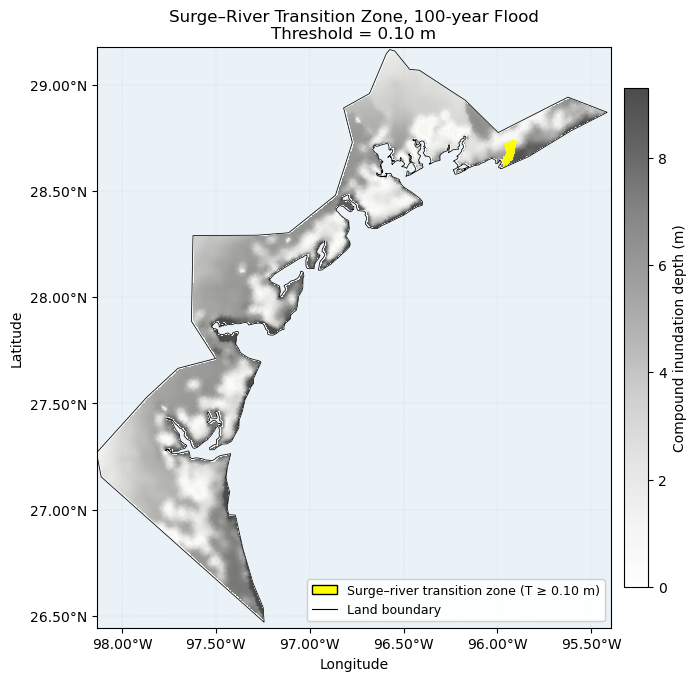

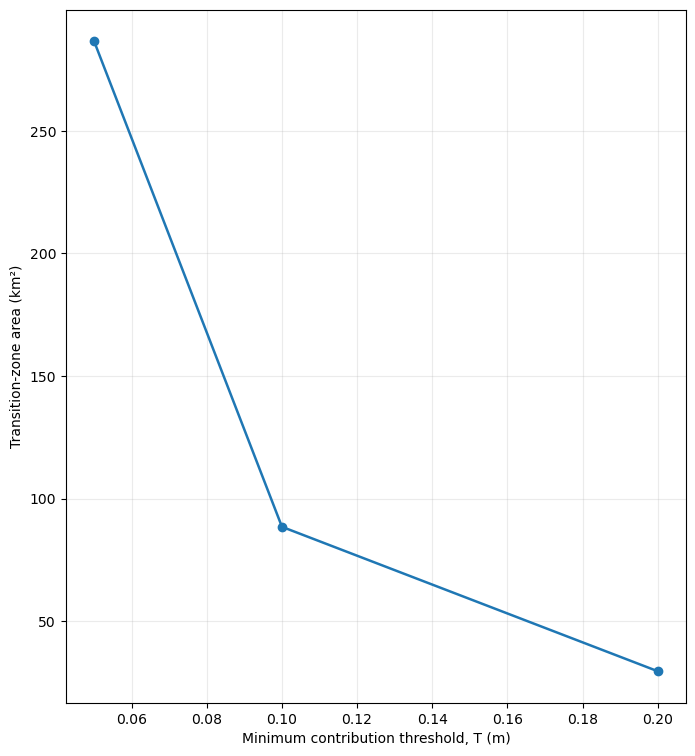


Analysis completed.
Outputs saved to:
D:\Phd Research\Final_Raster\Surge_River_Transition


In [18]:
import rasterio, geopandas as gpd, numpy as np, pandas as pd, matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.features import shapes, geometry_mask
from shapely.geometry import shape
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
import contextily as ctx

# ============================================================
# FILE PATHS
# ============================================================
compound_file=r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"
surge_file=r"D:\Phd Research\Final_Raster\Inundation_100yr_Surge+SLR.tif"
river_file=r"D:\Phd Research\Final_Raster\inundation only due ot SLR+Q_v1_stat.tif"
land_file=r"zip://D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
out_dir=Path(r"D:\Phd Research\Final_Raster\Surge_River_Transition"); out_dir.mkdir(parents=True,exist_ok=True)

# Thresholds for sensitivity analysis
thresholds=[0.05,0.10,0.20]
main_threshold=0.10
wet_threshold=0.01

# ============================================================
# READ COMPOUND RASTER AS REFERENCE GRID
# ============================================================
with rasterio.open(compound_file) as src:
    compound=src.read(1).astype("float32"); profile=src.profile.copy(); transform=src.transform
    crs=src.crs; nodata=src.nodata; bounds=src.bounds; width,height=src.width,src.height

if nodata is not None: compound[compound==nodata]=np.nan

# ============================================================
# READ + ALIGN OTHER RASTERS TO COMPOUND GRID
# ============================================================
def read_align_raster(path):
    with rasterio.open(path) as src:
        arr=src.read(1).astype("float32"); src_nodata=src.nodata
        if src_nodata is not None: arr[arr==src_nodata]=np.nan
        if src.crs==crs and src.transform==transform and src.width==width and src.height==height: return arr
        dst=np.full((height,width),np.nan,dtype="float32")
        reproject(arr,dst,src_transform=src.transform,src_crs=src.crs,dst_transform=transform,dst_crs=crs,
                  src_nodata=np.nan,dst_nodata=np.nan,resampling=Resampling.bilinear)
        return dst

surge=read_align_raster(surge_file)
river=read_align_raster(river_file)

# ============================================================
# READ LAND BOUNDARY AND CREATE LAND MASK
# ============================================================
land=gpd.read_file(land_file)
if land.crs!=crs: land=land.to_crs(crs)

land_mask=geometry_mask(land.geometry,out_shape=(height,width),transform=transform,invert=True)

# Restrict analysis to land
compound[~land_mask]=np.nan; surge[~land_mask]=np.nan; river[~land_mask]=np.nan

# Treat negative depths as dry / numerical artifacts
compound[compound<0]=0; surge[surge<0]=0; river[river<0]=0

# ============================================================
# VALID / WET DOMAIN
# ============================================================
valid=np.isfinite(compound)&np.isfinite(surge)&np.isfinite(river)
wet=valid&((compound>wet_threshold)|(surge>wet_threshold)|(river>wet_threshold))

# ============================================================
# COMPOUND ENHANCEMENT
# ============================================================
# Compound minus surge-only
delta_CS=compound-surge

# Compound minus river-only
delta_CR=compound-river

# ============================================================
# SINGLE-DRIVER DOMINANCE INDEX
# D = (Surge - River) / (Surge + River)
# +1 = surge dominated; -1 = river dominated; 0 = similar
# ============================================================
denom=surge+river
dominance=np.full(compound.shape,np.nan,dtype="float32")
idx=wet&(denom>wet_threshold)
dominance[idx]=(surge[idx]-river[idx])/denom[idx]

# ============================================================
# FUNCTION TO WRITE GEOTIFF
# ============================================================
def write_raster(array,filename,dtype="float32",nodata_out=-9999):
    out=np.where(np.isfinite(array),array,nodata_out)
    p=profile.copy(); p.update(dtype=dtype,count=1,nodata=nodata_out,compress="lzw")
    with rasterio.open(out_dir/filename,"w",**p) as dst: dst.write(out.astype(dtype),1)

# Save diagnostic rasters
write_raster(delta_CS,"Compound_minus_Surge.tif")
write_raster(delta_CR,"Compound_minus_River.tif")
write_raster(dominance,"Surge_River_Dominance_Index.tif")

# ============================================================
# PIXEL AREA
# ============================================================
pixel_area_m2=abs(transform.a*transform.e)
pixel_area_km2=pixel_area_m2/1e6

# ============================================================
# TRANSITION-ZONE SENSITIVITY ANALYSIS
# ============================================================
summary=[]

for T in thresholds:

    # Compound must exceed BOTH single-driver depths by at least T
    transition=wet&(delta_CS>=T)&(delta_CR>=T)

    area_km2=transition.sum()*pixel_area_km2
    flooded_compound_area=(valid&(compound>wet_threshold)).sum()*pixel_area_km2
    pct_compound=100*area_km2/flooded_compound_area if flooded_compound_area>0 else np.nan

    summary.append({
        "Threshold_m":T,
        "Transition_Area_km2":area_km2,
        "Percent_of_Compound_Flooded_Area":pct_compound,
        "Mean_Compound_Depth_m":np.nanmean(compound[transition]) if transition.any() else np.nan,
        "Mean_Surge_Depth_m":np.nanmean(surge[transition]) if transition.any() else np.nan,
        "Mean_River_Depth_m":np.nanmean(river[transition]) if transition.any() else np.nan,
        "Mean_Compound_minus_Surge_m":np.nanmean(delta_CS[transition]) if transition.any() else np.nan,
        "Mean_Compound_minus_River_m":np.nanmean(delta_CR[transition]) if transition.any() else np.nan
    })

    transition_raster=np.full(compound.shape,np.nan,dtype="float32")
    transition_raster[valid]=0; transition_raster[transition]=1
    write_raster(transition_raster,f"Transition_zone_{int(T*100):02d}cm.tif")

summary_df=pd.DataFrame(summary)
summary_df.to_csv(out_dir/"Transition_zone_threshold_sensitivity.csv",index=False)

print("\nTransition-zone sensitivity:")
print(summary_df.round(3).to_string(index=False))

# ============================================================
# MAIN 0.10-m CLASSIFICATION
# ============================================================
T=main_threshold
transition=wet&(delta_CS>=T)&(delta_CR>=T)

# 0 = dry/no meaningful flood
# 1 = river dominated
# 2 = surge-river transition
# 3 = surge dominated
# 4 = mixed/ambiguous
classification=np.full(compound.shape,np.nan,dtype="float32")
classification[valid]=0

# Compare compound result with each single-driver result
surge_distance=np.abs(compound-surge)
river_distance=np.abs(compound-river)

river_dom=wet&~transition&(river_distance<surge_distance)
surge_dom=wet&~transition&(surge_distance<river_distance)
mixed=wet&~transition&np.isclose(surge_distance,river_distance,atol=0.01)

classification[river_dom]=1
classification[transition]=2
classification[surge_dom]=3
classification[mixed]=4

write_raster(classification,"Surge_River_Flood_Regime_10cm.tif")

# ============================================================
# TRANSITION ZONE TO SHAPEFILE
# ============================================================
transition_uint8=transition.astype("uint8")

geoms=[{"properties":{"Transition":int(v)},"geometry":shape(g)}
       for g,v in shapes(transition_uint8,mask=transition,transform=transform) if v==1]

if geoms:
    transition_gdf=gpd.GeoDataFrame.from_features(geoms,crs=crs)
    transition_gdf=transition_gdf.dissolve(by="Transition").reset_index()
    transition_gdf["Area_km2"]=transition_gdf.geometry.area/1e6
    transition_gdf.to_file(out_dir/"Surge_River_Transition_Zone_10cm.shp")

# ============================================================
# FUNCTION: REPROJECT RASTER TO LAT/LON FOR PLOTTING
# ============================================================
def to_ll(a,resamp):
    tr,w,h=calculate_default_transform(crs,"EPSG:4326",width,height,*bounds)
    out=np.full((h,w),np.nan,dtype="float32")
    reproject(a,out,src_transform=transform,src_crs=crs,dst_transform=tr,dst_crs="EPSG:4326",
              src_nodata=np.nan,dst_nodata=np.nan,resampling=resamp)
    return out,[tr.c,tr.c+w*tr.a,tr.f+h*tr.e,tr.f]

# Reproject plotting layers
compound_ll,extent_ll=to_ll(compound,Resampling.bilinear)
transition_ll,_=to_ll(np.where(transition,1,np.nan).astype("float32"),Resampling.nearest)
land_ll=land.to_crs("EPSG:4326")

# ============================================================
# FIGURE 4: PUBLICATION-STYLE TRANSITION-ZONE MAP
# NO ONLINE BASEMAP / NO API KEY / NO WATERMARK
# ============================================================
from rasterio.warp import calculate_default_transform, reproject, Resampling
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# Reproject raster from model CRS to latitude/longitude
def to_ll(a,resamp):
    tr,w,h=calculate_default_transform(crs,"EPSG:4326",width,height,*bounds)
    out=np.full((h,w),np.nan,dtype="float32")
    reproject(a,out,src_transform=transform,src_crs=crs,dst_transform=tr,dst_crs="EPSG:4326",
              src_nodata=np.nan,dst_nodata=np.nan,resampling=resamp)
    return out,[tr.c,tr.c+w*tr.a,tr.f+h*tr.e,tr.f]

# Reproject plotting layers
compound_ll,extent_ll=to_ll(compound,Resampling.bilinear)
transition_ll,_=to_ll(np.where(transition,1,np.nan).astype("float32"),Resampling.nearest)
land_ll=land.to_crs("EPSG:4326")

# Create figure
fig,ax=plt.subplots(figsize=(8,9))
ax.set_xlim(extent_ll[0],extent_ll[1]); ax.set_ylim(extent_ll[2],extent_ll[3])
ax.set_facecolor("#EAF2F8")   # light blue ocean/background

# Plot land area as light background
land_ll.plot(ax=ax,facecolor="#F7F7F2",edgecolor="none",zorder=1)

# Plot compound inundation depth
compound_plot=np.ma.masked_where((~np.isfinite(compound_ll))|(compound_ll<=wet_threshold),compound_ll)
vmax=np.nanpercentile(compound_ll[np.isfinite(compound_ll)&(compound_ll>wet_threshold)],98)
im=ax.imshow(compound_plot,extent=extent_ll,origin="upper",cmap="Greys",alpha=.70,vmin=0,vmax=vmax,zorder=2)

# Compound inundation depth colorbar
cbar=plt.colorbar(im,ax=ax,shrink=.72,pad=.02)
cbar.set_label("Compound inundation depth (m)",fontsize=10)

# Plot surge-river transition zone in yellow
transition_plot=np.ma.masked_invalid(transition_ll)
ax.imshow(transition_plot,extent=extent_ll,origin="upper",cmap=ListedColormap(["yellow"]),
          vmin=0,vmax=1,alpha=.95,zorder=3)

# Plot coastline / land boundary
land_ll.boundary.plot(ax=ax,color="black",linewidth=.55,zorder=4)

# Add legend
legend=[Patch(facecolor="yellow",edgecolor="black",label=f"Surge–river transition zone (T ≥ {T:.2f} m)"),
        Line2D([0],[0],color="black",linewidth=.8,label="Land boundary")]
ax.legend(handles=legend,loc="lower right",fontsize=9,frameon=True,framealpha=.95)

# Latitude/longitude axes
ax.set_xlabel("Longitude",fontsize=10); ax.set_ylabel("Latitude",fontsize=10)
ax.xaxis.set_major_locator(MultipleLocator(.5)); ax.yaxis.set_major_locator(MultipleLocator(.5))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p:f"{abs(x):.2f}°W"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,p:f"{y:.2f}°N"))

# Add subtle geographic grid
ax.grid(True,linewidth=.35,linestyle="--",alpha=.35,zorder=0)

# Title
ax.set_title(f"Surge–River Transition Zone, 100-year Flood\nThreshold = {T:.2f} m",fontsize=12)

# Save and display
plt.savefig(out_dir/"Surge_River_Transition_Zone_10cm_Publication.png",dpi=600,bbox_inches="tight")
plt.show()
# ============================================================
# FIGURE 5: THRESHOLD SENSITIVITY
# ============================================================
fig, ax = plt.subplots(figsize=(8, 9))

ax.plot(
    summary_df["Threshold_m"],
    summary_df["Transition_Area_km2"],
    marker="o",
    linewidth=1.8
)

ax.set_xlabel("Minimum contribution threshold, T (m)")
ax.set_ylabel("Transition-zone area (km²)")
ax.grid(alpha=0.25)

plt.savefig(out_dir / "Transition_Threshold_Sensitivity.png", dpi=400, bbox_inches="tight")
plt.show()
print("\nAnalysis completed.")
print(f"Outputs saved to:\n{out_dir}")